In [1]:
import os
import numpy as np
import pandas as pd
import tensorflow as tf
import time

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models
from tensorflow.keras.applications import Xception
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

data_dir = "/kaggle/input/cell-images-for-detecting-malaria/cell_images"
print("Data dir:", data_dir)
print("Classes:", os.listdir(data_dir))


2025-12-07 08:28:33.882208: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1765096113.905282     403 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1765096113.912015     403 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

Data dir: /kaggle/input/cell-images-for-detecting-malaria/cell_images
Classes: ['Uninfected', 'Parasitized', 'cell_images']


In [2]:
image_paths = []
labels = []

for label_name in ["Parasitized", "Uninfected"]:
    class_dir = os.path.join(data_dir, label_name)
    for fname in os.listdir(class_dir):
        if fname.lower().endswith((".png", ".jpg", ".jpeg")):
            image_paths.append(os.path.join(class_dir, fname))
            labels.append(1 if label_name == "Parasitized" else 0)

image_paths = np.array(image_paths)
labels = np.array(labels)

print("Total images:", len(image_paths))
print("Parasitized:", np.sum(labels == 1))
print("Uninfected:", np.sum(labels == 0))

# 80/20 split
train_paths, test_paths, train_labels, test_labels = train_test_split(
    image_paths,
    labels,
    test_size=0.2,
    stratify=labels,
    random_state=42
)

print("Train size:", len(train_paths))
print("Test size:", len(test_paths))


Total images: 27558
Parasitized: 13779
Uninfected: 13779
Train size: 22046
Test size: 5512


In [3]:
img_size_xception = (299, 299)
batch_size = 32

train_df = pd.DataFrame({
    "filepath": train_paths,
    "label": np.where(train_labels == 1, "Parasitized", "Uninfected")
})

test_df = pd.DataFrame({
    "filepath": test_paths,
    "label": np.where(test_labels == 1, "Parasitized", "Uninfected")
})

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True,
    validation_split=0.1
)

test_datagen = ImageDataGenerator(rescale=1./255)

train_gen = train_datagen.flow_from_dataframe(
    train_df,
    x_col="filepath",
    y_col="label",
    target_size=img_size_xception,
    class_mode="binary",
    batch_size=batch_size,
    subset="training",
    shuffle=True
)

val_gen = train_datagen.flow_from_dataframe(
    train_df,
    x_col="filepath",
    y_col="label",
    target_size=img_size_xception,
    class_mode="binary",
    batch_size=batch_size,
    subset="validation",
    shuffle=False
)

test_gen = test_datagen.flow_from_dataframe(
    test_df,
    x_col="filepath",
    y_col="label",
    target_size=img_size_xception,
    class_mode="binary",
    batch_size=batch_size,
    shuffle=False
)

print("Generators created for Xception (299x299 input)")


Found 19842 validated image filenames belonging to 2 classes.
Found 2204 validated image filenames belonging to 2 classes.
Found 5512 validated image filenames belonging to 2 classes.
Generators created for Xception (299x299 input)


In [4]:
input_shape = (img_size_xception[0], img_size_xception[1], 3)

base_model = Xception(
    include_top=False,
    weights="imagenet",
    input_shape=input_shape
)

base_model.trainable = True  # fine-tune all layers

# Custom head: GlobalAveragePooling instead of Flatten (Xception's typical pattern)
inputs = layers.Input(shape=input_shape)
x = base_model(inputs, training=True)
x = layers.GlobalAveragePooling2D()(x)
x = layers.BatchNormalization()(x)
x = layers.Dense(256, activation="relu")(x)
x = layers.Dropout(0.5)(x)
x = layers.BatchNormalization()(x)
x = layers.Dense(32, activation="relu")(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(1, activation="sigmoid")(x)

model = models.Model(inputs, outputs)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.AUC(name="auc"),
        tf.keras.metrics.Precision(name="precision"),
        tf.keras.metrics.Recall(name="recall")
    ]
)

model.summary()

callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True
    )
]

start_time = time.time()

history = model.fit(
    train_gen,
    epochs=15,
    validation_data=val_gen,
    callbacks=callbacks
)

end_time = time.time()
print(f"Xception training time: {(end_time - start_time)/60:.2f} minutes")


I0000 00:00:1765096189.019235     403 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1765096189.019895     403 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 299, 299, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ xception (Functional)           │ (None, 10, 10, 2048)   │    20,861,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 2048)           │         8,192 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         8,224 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,403,497 (81.65 MB)

 Trainable params: 21,344,361 (81.42 MB)

...

Epoch 1/15


I0000 00:00:1765096217.639348     437 service.cc:148] XLA service 0x789b6c003d00 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1765096217.639422     437 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1765096217.639428     437 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1765096221.286178     437 cuda_dnn.cc:529] Loaded cuDNN version 90300
2025-12-07 08:30:28.019742: E external/local_xla/xla/service/slow_operation_alarm.cc:65] Trying algorithm eng3{k11=0} for conv (f32[32,128,147,147]{3,2,1,0}, u8[0]{0}) custom-call(f32[32,128,147,147]{3,2,1,0}, f32[128,128,1,1]{3,2,1,0}), window={size=1x1}, dim_labels=bf01_oi01->bf01, custom_call_target="__cudnn$convForward", backend_config={"cudnn_conv_backend_config":{"activation_mode":"kNone","conv_result_scale":1,"leakyrelu_alpha":0,"side_input_scale":0},"force_earliest_schedule":false,"operation_queue_id":"0

106/621 ━━━━━━━━━━━━━━━━━━━━ 8:21 974ms/step - accuracy: 0.7696 - auc: 0.8537 - loss: 0.4592 - precision: 0.7761 - recall: 0.7602

E0000 00:00:1765096379.408607     438 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1765096379.551903     438 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1765096379.931928     438 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.
E0000 00:00:1765096380.077584     438 gpu_timer.cc:82] Delay kernel timed out: measured time has sub-optimal accuracy. There may be a missing warmup execution, please investigate in Nsight Systems.


621/621 ━━━━━━━━━━━━━━━━━━━━ 766s 1s/step - accuracy: 0.8922 - auc: 0.9510 - loss: 0.2565 - precision: 0.8899 - recall: 0.8963 - val_accuracy: 0.9555 - val_auc: 0.9889 - val_loss: 0.1280 - val_precision: 0.9361 - val_recall: 0.9771
Epoch 2/15
621/621 ━━━━━━━━━━━━━━━━━━━━ 652s 1s/step - accuracy: 0.9640 - auc: 0.9902 - loss: 0.1153 - precision: 0.9577 - recall: 0.9716 - val_accuracy: 0.9596 - val_auc: 0.9911 - val_loss: 0.1125 - val_precision: 0.9467 - val_recall: 0.9735
Epoch 3/15
621/621 ━━━━━━━━━━━━━━━━━━━━ 653s 1s/step - accuracy: 0.9654 - auc: 0.9910 - loss: 0.1083 - precision: 0.9585 - recall: 0.9730 - val_accuracy: 0.9632 - val_auc: 0.9920 - val_loss: 0.1054 - val_precision: 0.9584 - val_recall: 0.9680
Epoch 4/15
621/621 ━━━━━━━━━━━━━━━━━━━━ 651s 1s/step - accuracy: 0.9680 - auc: 0.9925 - loss: 0.0994 - precision: 0.9629 - recall: 0.9741 - val_accuracy: 0.9596 - val_auc: 0.9920 - val_loss: 0.1063 - val_precision: 0.9499 - val_recall: 0.9698
Epoch 5/15
621/621 ━━━━━━━━━━━━━━━━━━━━

In [5]:
# Evaluating 'model' on 'test_gen'
test_loss_x, test_acc_x, test_auc_x, test_prec_x, test_rec_x = model.evaluate(test_gen)
test_f1_x = 2 * test_prec_x * test_rec_x / (test_prec_x + test_rec_x)

print("Xception Test loss:", test_loss_x)
print("Xception Test accuracy:", test_acc_x)
print("Xception Test AUC:", test_auc_x)
print("Xception Test precision:", test_prec_x)
print("Xception Test recall:", test_rec_x)
print("Xception Test F1:", test_f1_x)

173/173 ━━━━━━━━━━━━━━━━━━━━ 76s 442ms/step - accuracy: 0.9697 - auc: 0.9942 - loss: 0.0876 - precision: 0.9630 - recall: 0.9781
Xception Test loss: 0.0835069939494133
Xception Test accuracy: 0.9700652956962585
Xception Test AUC: 0.9944590330123901
Xception Test precision: 0.9621833562850952
Xception Test recall: 0.9785921573638916
Xception Test F1: 0.9703183905451505


✓ Saved: xception_confusion_matrix.png


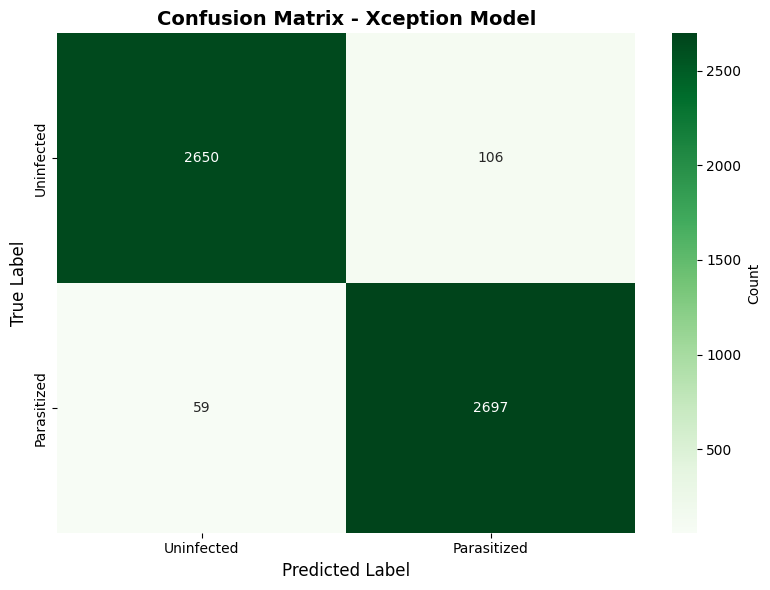


XCEPTION - CLASSIFICATION REPORT
              precision    recall  f1-score   support

  Uninfected       0.98      0.96      0.97      2756
 Parasitized       0.96      0.98      0.97      2756

    accuracy                           0.97      5512
   macro avg       0.97      0.97      0.97      5512
weighted avg       0.97      0.97      0.97      5512

✓ Saved: xception_roc_curve.png


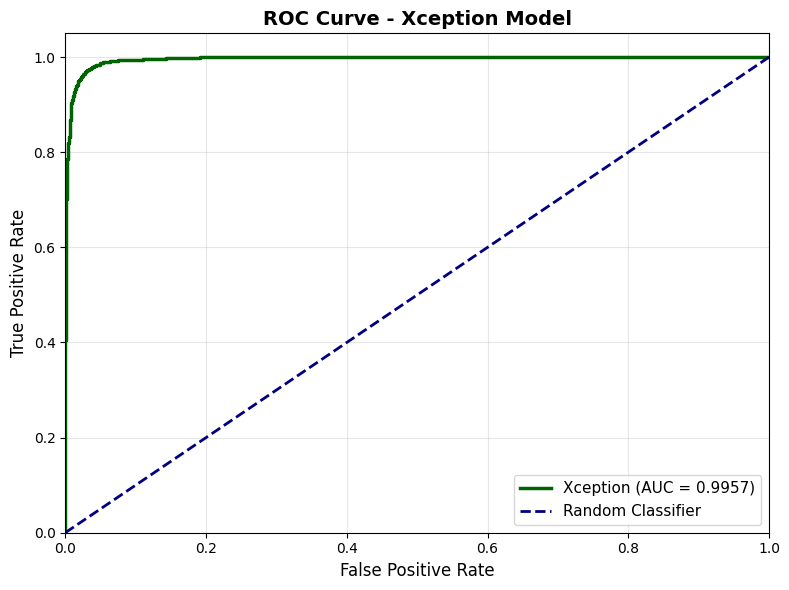

✓ Saved: xception_precision_recall_curve.png


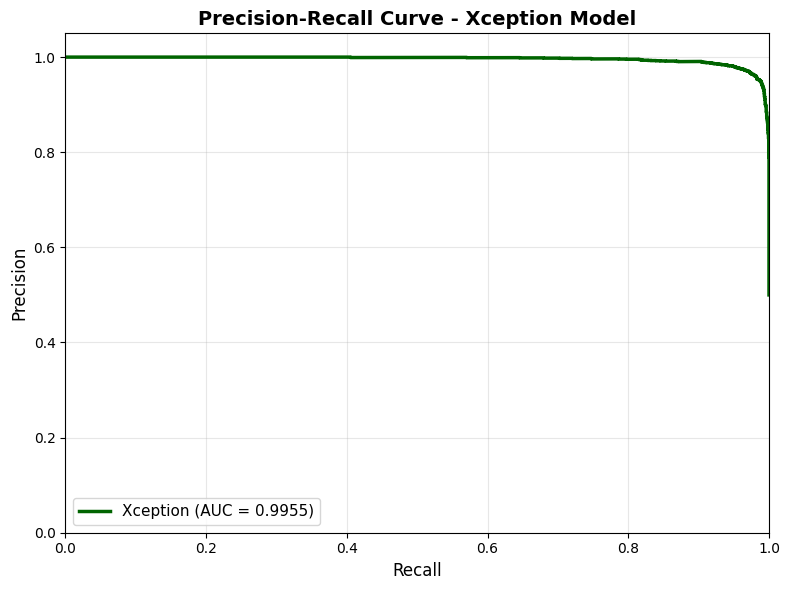

✓ Saved: xception_training_history.png


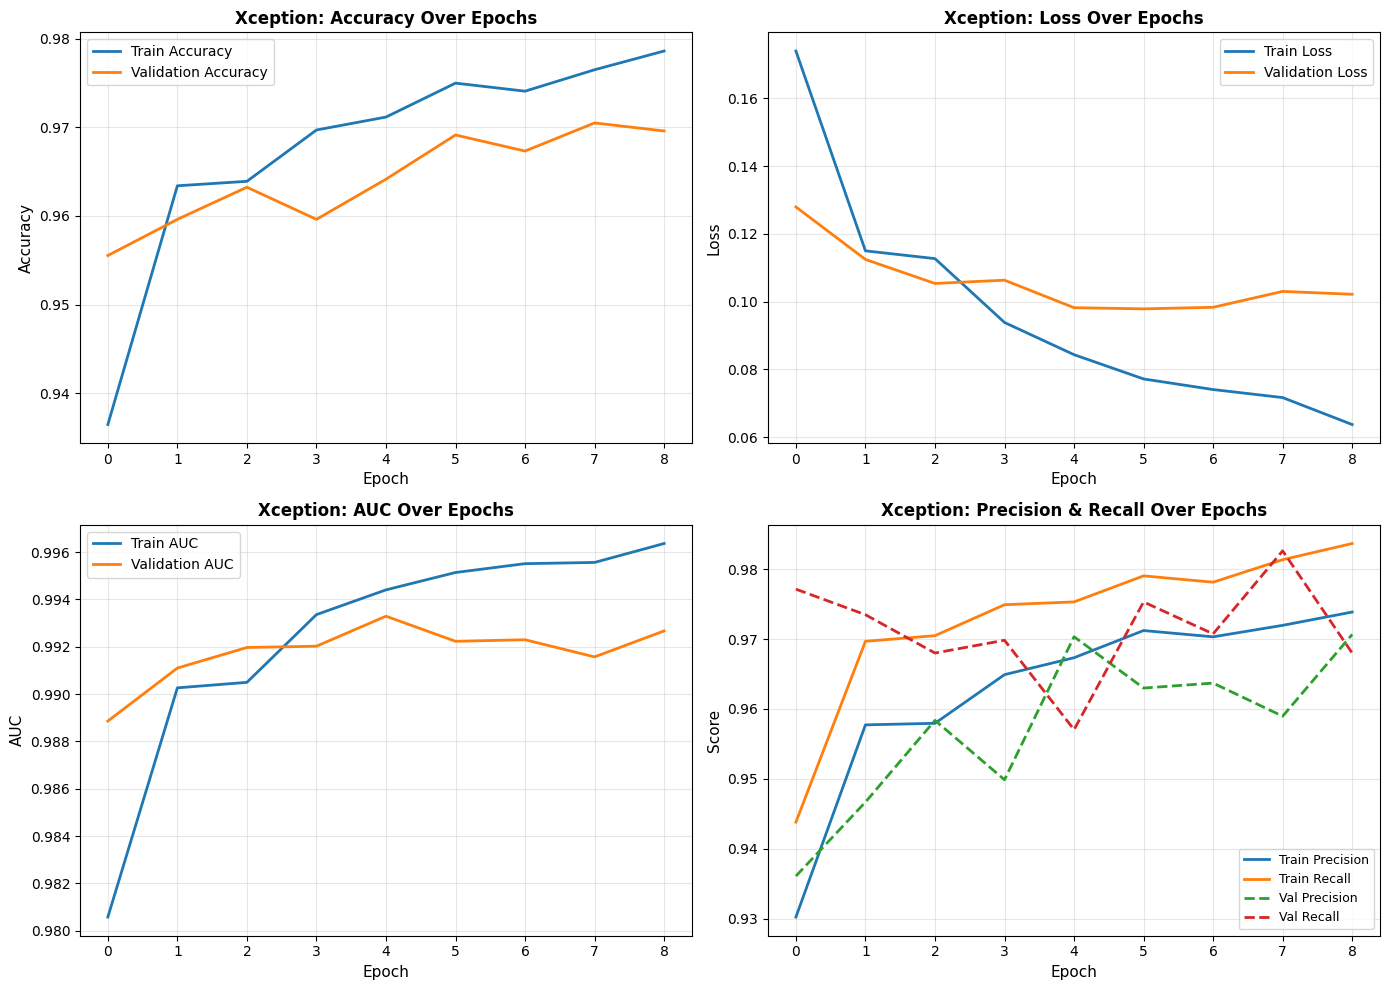


COMPARISON: EfficientNetB2 vs Xception

   Metric EfficientNetB2 (Paper's Baseline) EfficientNetB2 ( Reproduction) Xception ( Improvement)
 Accuracy                            97.57%                         95.36%                  97.01%
Precision                            98.62%                         95.42%                  96.22%
   Recall                            96.88%                         95.28%                  97.86%
 F1-Score                            97.55%                         95.35%                  97.03%
      AUC                            0.9921                         0.9881                  0.9945
     Loss                            0.0995                         0.1386                  0.0835

✓ Saved: model_comparison.csv

XCEPTION - RESULTS SUMMARY

       Class Precision Recall F1-Score Support
  Uninfected    0.9782 0.9615   0.9698    2756
 Parasitized    0.9622 0.9786   0.9703    2756
Weighted Avg    0.9702 0.9701   0.9701    5512

✓ Saved: xception

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc, precision_recall_curve
import numpy as np
import pandas as pd

# ==========================================
# GET PREDICTIONS (Xception)
# ==========================================
test_gen.reset()
preds_xcp = model.predict(test_gen, verbose=0)
y_pred_xcp = (preds_xcp > 0.5).astype(int).flatten()
y_true = test_gen.classes

# ==========================================
# 1. CONFUSION MATRIX
# ==========================================
cm_xcp = confusion_matrix(y_true, y_pred_xcp)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_xcp, annot=True, fmt='d', cmap='Greens', 
            xticklabels=["Uninfected", "Parasitized"], 
            yticklabels=["Uninfected", "Parasitized"],
            cbar_kws={"label": "Count"})
plt.title("Confusion Matrix - Xception Model", fontsize=14, fontweight='bold')
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.savefig('xception_confusion_matrix.png', dpi=300, bbox_inches='tight')
print("✓ Saved: xception_confusion_matrix.png")
plt.show()

# ==========================================
# 2. CLASSIFICATION REPORT
# ==========================================
print("\n" + "=" * 60)
print("XCEPTION - CLASSIFICATION REPORT")
print("=" * 60)
print(classification_report(y_true, y_pred_xcp, 
                           target_names=["Uninfected", "Parasitized"]))

report_dict_xcp = classification_report(y_true, y_pred_xcp, 
                                        target_names=["Uninfected", "Parasitized"],
                                        output_dict=True)

# ==========================================
# 3. ROC CURVE
# ==========================================
fpr_xcp, tpr_xcp, _ = roc_curve(y_true, preds_xcp)
roc_auc_xcp = auc(fpr_xcp, tpr_xcp)

plt.figure(figsize=(8, 6))
plt.plot(fpr_xcp, tpr_xcp, color='darkgreen', lw=2.5, label=f'Xception (AUC = {roc_auc_xcp:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve - Xception Model', fontsize=14, fontweight='bold')
plt.legend(loc="lower right", fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('xception_roc_curve.png', dpi=300, bbox_inches='tight')
print("✓ Saved: xception_roc_curve.png")
plt.show()

# ==========================================
# 4. PRECISION-RECALL CURVE
# ==========================================
precision_xcp, recall_xcp, _ = precision_recall_curve(y_true, preds_xcp)
pr_auc_xcp = auc(recall_xcp, precision_xcp)

plt.figure(figsize=(8, 6))
plt.plot(recall_xcp, precision_xcp, color='darkgreen', lw=2.5, label=f'Xception (AUC = {pr_auc_xcp:.4f})')
plt.xlabel('Recall', fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.title('Precision-Recall Curve - Xception Model', fontsize=14, fontweight='bold')
plt.legend(loc="best", fontsize=11)
plt.grid(alpha=0.3)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.tight_layout()
plt.savefig('xception_precision_recall_curve.png', dpi=300, bbox_inches='tight')
print("✓ Saved: xception_precision_recall_curve.png")
plt.show()

# ==========================================
# 5. TRAINING HISTORY (Xception)
# ==========================================
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

axes[0, 0].plot(history.history['accuracy'], label='Train Accuracy', linewidth=2)
axes[0, 0].plot(history.history['val_accuracy'], label='Validation Accuracy', linewidth=2)
axes[0, 0].set_xlabel('Epoch', fontsize=11)
axes[0, 0].set_ylabel('Accuracy', fontsize=11)
axes[0, 0].set_title('Xception: Accuracy Over Epochs', fontsize=12, fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(alpha=0.3)

axes[0, 1].plot(history.history['loss'], label='Train Loss', linewidth=2)
axes[0, 1].plot(history.history['val_loss'], label='Validation Loss', linewidth=2)
axes[0, 1].set_xlabel('Epoch', fontsize=11)
axes[0, 1].set_ylabel('Loss', fontsize=11)
axes[0, 1].set_title('Xception: Loss Over Epochs', fontsize=12, fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

axes[1, 0].plot(history.history['auc'], label='Train AUC', linewidth=2)
axes[1, 0].plot(history.history['val_auc'], label='Validation AUC', linewidth=2)
axes[1, 0].set_xlabel('Epoch', fontsize=11)
axes[1, 0].set_ylabel('AUC', fontsize=11)
axes[1, 0].set_title('Xception: AUC Over Epochs', fontsize=12, fontweight='bold')
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

axes[1, 1].plot(history.history['precision'], label='Train Precision', linewidth=2)
axes[1, 1].plot(history.history['recall'], label='Train Recall', linewidth=2)
axes[1, 1].plot(history.history['val_precision'], label='Val Precision', linewidth=2, linestyle='--')
axes[1, 1].plot(history.history['val_recall'], label='Val Recall', linewidth=2, linestyle='--')
axes[1, 1].set_xlabel('Epoch', fontsize=11)
axes[1, 1].set_ylabel('Score', fontsize=11)
axes[1, 1].set_title('Xception: Precision & Recall Over Epochs', fontsize=12, fontweight='bold')
axes[1, 1].legend(fontsize=9)
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('xception_training_history.png', dpi=300, bbox_inches='tight')
print("✓ Saved: xception_training_history.png")
plt.show()

# ==========================================
# 6. COMPARISON TABLE (EfficientNetB2 vs Xception)
# ==========================================
print("\n" + "=" * 60)
print("COMPARISON: EfficientNetB2 vs Xception")
print("=" * 60)

comparison_data = {
    "Metric": ["Accuracy", "Precision", "Recall", "F1-Score", "AUC", "Loss"],
    "EfficientNetB2 (Paper's Baseline)": ["97.57%", "98.62%", "96.88%", "97.55%", "0.9921", "0.0995"],
    "EfficientNetB2 ( Reproduction)": ["95.36%", "95.42%", "95.28%", "95.35%", "0.9881", "0.1386"],
    "Xception ( Improvement)": [f"{test_acc_x*100:.2f}%", 
                                     f"{test_prec_x*100:.2f}%", 
                                     f"{test_rec_x*100:.2f}%", 
                                     f"{test_f1_x*100:.2f}%", 
                                     f"{test_auc_x:.4f}", 
                                     f"{test_loss_x:.4f}"]
}

comparison_df = pd.DataFrame(comparison_data)
print("\n" + comparison_df.to_string(index=False))
comparison_df.to_csv('model_comparison.csv', index=False)
print("\n✓ Saved: model_comparison.csv")

# ==========================================
# 7. XCEPTION RESULTS SUMMARY TABLE
# ==========================================
summary_data_xcp = {
    "Class": ["Uninfected", "Parasitized", "Weighted Avg"],
    "Precision": [
        f"{report_dict_xcp['Uninfected']['precision']:.4f}",
        f"{report_dict_xcp['Parasitized']['precision']:.4f}",
        f"{report_dict_xcp['weighted avg']['precision']:.4f}"
    ],
    "Recall": [
        f"{report_dict_xcp['Uninfected']['recall']:.4f}",
        f"{report_dict_xcp['Parasitized']['recall']:.4f}",
        f"{report_dict_xcp['weighted avg']['recall']:.4f}"
    ],
    "F1-Score": [
        f"{report_dict_xcp['Uninfected']['f1-score']:.4f}",
        f"{report_dict_xcp['Parasitized']['f1-score']:.4f}",
        f"{report_dict_xcp['weighted avg']['f1-score']:.4f}"
    ],
    "Support": [
        f"{int(report_dict_xcp['Uninfected']['support'])}",
        f"{int(report_dict_xcp['Parasitized']['support'])}",
        f"{int(report_dict_xcp['weighted avg']['support'])}"
    ]
}

summary_df_xcp = pd.DataFrame(summary_data_xcp)
print("\n" + "=" * 60)
print("XCEPTION - RESULTS SUMMARY")
print("=" * 60)
print("\n" + summary_df_xcp.to_string(index=False))
summary_df_xcp.to_csv('xception_results_summary.csv', index=False)
print("\n✓ Saved: xception_results_summary.csv")

print("\n" + "=" * 60)
print("✓ ALL XCEPTION VISUALIZATIONS & TABLES GENERATED")
print("=" * 60)
print("\nGenerated files:")
print("  • xception_confusion_matrix.png")
print("  • xception_roc_curve.png")
print("  • xception_precision_recall_curve.png")
print("  • xception_training_history.png")
print("  • model_comparison.csv")
print("  • xception_results_summary.csv")
